# 04 — Strategy Simulation

This notebook drives the strategy layer directly: a Monte Carlo engine comparing "stay out" vs "pit at lap X with compound Y", a pit-window sweep to find the optimal stop, the opponent undercut model, and the safety car hazard model.

**Caveat up front:** the simulation below uses stylised pace/degradation parameters for clarity — the same structure the `/whatif` endpoint uses. The production endpoint swaps in model-quantile draws instead of Gaussian noise.

In [1]:
import sys, pathlib
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#080c14", "axes.facecolor": "#0f172a",
    "axes.edgecolor": "#1e293b", "xtick.color": "#8b9bb4",
    "ytick.color": "#8b9bb4", "text.color": "#e2e8f0",
    "axes.labelcolor": "#8b9bb4", "savefig.facecolor": "#080c14",
})

def simulate_strategy(target_pit_lap, target_compound, push_delta,
                      remaining_laps, current_lap, curr_compound="MEDIUM", curr_age=15,
                      n_sims=5000, seed=42):
    """Monte Carlo: stay out vs pit at target_pit_lap on target_compound."""
    rng = np.random.default_rng(seed)
    compound_pace = {"SOFT": -0.4, "MEDIUM": 0.0, "HARD": 0.35, "INTERMEDIATE": 0.8, "WET": 1.4}
    pit_loss = 22.0
    deg_per_lap = {"SOFT": 0.06, "MEDIUM": 0.025, "HARD": 0.012}
    base_pace = 85.0 + rng.normal(0, 0.1, n_sims)

    # Base: stay out on current rubber
    base_time = np.zeros(n_sims)
    for lap in range(remaining_laps):
        deg = deg_per_lap.get(curr_compound, 0.025) * (curr_age + lap)
        base_time += base_pace + deg + rng.normal(0, 0.3, n_sims)

    # What-if: pit at target_pit_lap
    whatif_time = np.zeros(n_sims)
    laps_before = max(0, target_pit_lap - current_lap)
    for lap in range(laps_before):
        deg = deg_per_lap.get(curr_compound, 0.025) * (curr_age + lap)
        whatif_time += base_pace + deg + rng.normal(0, 0.3, n_sims)
    whatif_time += pit_loss
    new_pace = base_pace + compound_pace.get(target_compound, 0)
    for lap in range(remaining_laps - laps_before):
        deg = deg_per_lap.get(target_compound, 0.025) * lap + push_delta
        whatif_time += new_pace + deg + rng.normal(0, 0.3, n_sims)

    return base_time, whatif_time

print("Engine ready")

Engine ready


## One scenario: pit lap 24, switch to HARD, push -0.2s

In [2]:
base_t, whatif_t = simulate_strategy(24, "HARD", -0.2, remaining_laps=30, current_lap=20)
delta = whatif_t - base_t
print(f"Base:   mean={base_t.mean():.1f}s  std={base_t.std():.1f}s")
print(f"What-if: mean={whatif_t.mean():.1f}s  std={whatif_t.std():.1f}s")
print(f"Net delta: {delta.mean():+.2f}s")
print(f"P(what-if faster): {(delta < 0).mean():.1%}")

Base:   mean=2572.0s  std=3.4s
What-if: mean=2581.4s  std=3.4s
Net delta: +9.38s
P(what-if faster): 0.0%


## Distributions

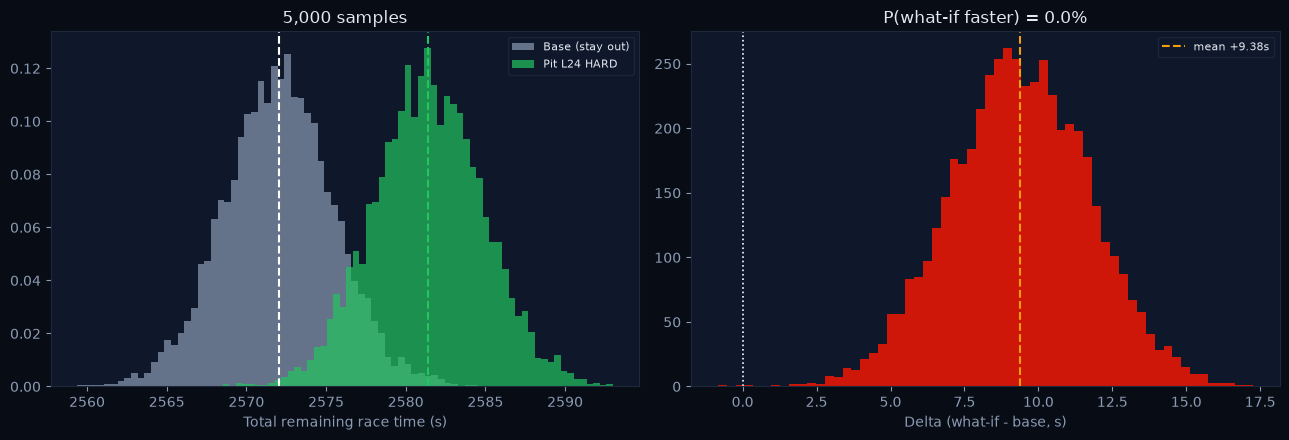

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#080c14")
for ax in (ax1, ax2):
    ax.set_facecolor("#0f172a")
    for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
    ax.tick_params(colors="#8b9bb4")

ax1.hist(base_t, bins=60, alpha=0.7, color="#8b9bb4", label="Base (stay out)", density=True)
ax1.hist(whatif_t, bins=60, alpha=0.7, color="#22c55e", label="Pit L24 HARD", density=True)
ax1.axvline(base_t.mean(), color="white", linewidth=1.5, linestyle="--")
ax1.axvline(whatif_t.mean(), color="#22c55e", linewidth=1.5, linestyle="--")
ax1.set_xlabel("Total remaining race time (s)"); ax1.set_title("5,000 samples")
ax1.legend(facecolor="#0f172a", edgecolor="#1e293b", fontsize=8)

ax2.hist(delta, bins=60, color="#ff1801" if delta.mean() >= 0 else "#22c55e", alpha=0.8)
ax2.axvline(0, color="white", linewidth=1.2, linestyle=":")
ax2.axvline(delta.mean(), color="#f59e0b", linewidth=1.5, linestyle="--", label=f"mean {delta.mean():+.2f}s")
ax2.set_xlabel("Delta (what-if - base, s)")
ax2.set_title(f"P(what-if faster) = {(delta < 0).mean():.1%}")
ax2.legend(facecolor="#0f172a", edgecolor="#1e293b", fontsize=8)
plt.tight_layout(); plt.show()

## Pit window sweep

Sweeping the pit lap across compounds. The interesting output is not one number but the shape: early stops lose to track position, late stops run out of laps to recoup the 22s, and the optimum sits where the fresh-tyre pace delta has enough laps to pay back the stop.

SOFT    : optimal pit lap 39  (delta +0.32s)
MEDIUM  : optimal pit lap 33  (delta -0.64s)
HARD    : optimal pit lap 32  (delta +4.19s)


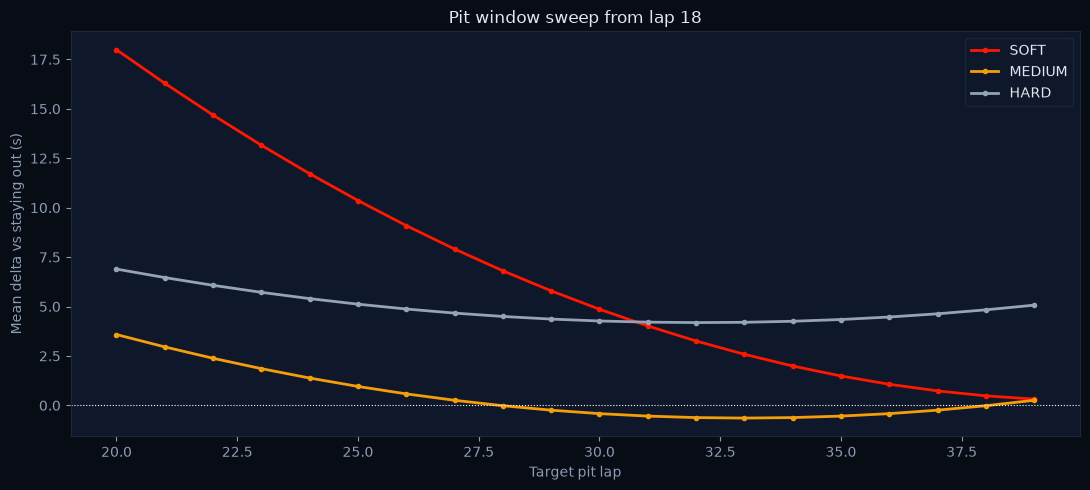

In [4]:
pit_laps = list(range(20, 40))
current_lap, remaining = 18, 45
compounds = ["SOFT", "MEDIUM", "HARD"]
colors_c = {"SOFT": "#ff1801", "MEDIUM": "#f59e0b", "HARD": "#94a3b8"}

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#080c14"); ax.set_facecolor("#0f172a")
for compound in compounds:
    deltas = []
    for pit in pit_laps:
        bt, wt = simulate_strategy(pit, compound, 0.0, remaining, current_lap, n_sims=1000)
        deltas.append((wt - bt).mean())
    ax.plot(pit_laps, deltas, marker="o", markersize=3, linewidth=2, label=compound, color=colors_c[compound])
    best = pit_laps[int(np.argmin(deltas))]
    print(f"{compound:8s}: optimal pit lap {best}  (delta {min(deltas):+.2f}s)")

ax.axhline(0, color="white", linewidth=0.8, linestyle=":")
ax.set_xlabel("Target pit lap"); ax.set_ylabel("Mean delta vs staying out (s)")
ax.set_title("Pit window sweep from lap 18")
ax.legend(facecolor="#0f172a", edgecolor="#1e293b")
for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
plt.tight_layout(); plt.show()

## Undercut threat model

If a rival within ~1.8s has fresher/softer rubber, they can undercut. Sweeping the gap to see where the tipping point is:

Scenario: driver on 21-lap MEDIUM vs rival on 19-lap HARD, gap 1.24s
  driver_number: 4
  estimated_delta_at_pit_exit_s: 0.04
  gap_s: 1.24
  is_overcut_threat: False
  is_undercut_threat: True
  recommended_action: HOLD
  rival_number: 1
  rival_pit_probability_3l: 0.55
  tyre_age_delta: -2


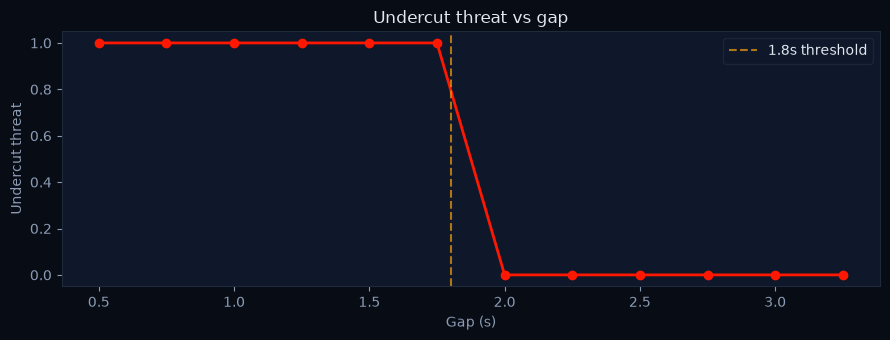

In [5]:
try:
    from pitwall.models.pit.opponent_model import OpponentPitModel
    model = OpponentPitModel(undercut_gap_threshold_s=1.8)

    threat = model.evaluate_undercut_threat(
        driver_number=4, driver_tyre_age=21, driver_compound="MEDIUM",
        rival_number=1, rival_tyre_age=19, rival_compound="HARD",
        gap_s=1.24,
    )
    print("Scenario: driver on 21-lap MEDIUM vs rival on 19-lap HARD, gap 1.24s")
    for k, v in sorted(vars(threat).items()):
        print(f"  {k}: {v}")

    gaps = np.arange(0.5, 3.5, 0.25)
    threats = []
    for g in gaps:
        t = model.evaluate_undercut_threat(
            driver_number=4, driver_tyre_age=21, driver_compound="MEDIUM",
            rival_number=1, rival_tyre_age=19, rival_compound="HARD", gap_s=float(g))
        threats.append(t.is_undercut_threat)

    fig, ax = plt.subplots(figsize=(9, 3.5))
    fig.patch.set_facecolor("#080c14"); ax.set_facecolor("#0f172a")
    ax.plot(gaps, threats, marker="o", color="#ff1801", linewidth=2)
    ax.axvline(1.8, color="#f59e0b", linestyle="--", alpha=0.7, label="1.8s threshold")
    ax.set_xlabel("Gap (s)"); ax.set_ylabel("Undercut threat")
    ax.set_title("Undercut threat vs gap")
    ax.legend(facecolor="#0f172a", edgecolor="#1e293b")
    for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Opponent model unavailable: {e}")

## Safety car hazard by circuit

Monaco historically neutralizes far more often than Monza. Lap 1 is the riskiest lap everywhere:

Circuit           Lap 1   Lap 20   Lap 50   Lap 70
--------------------------------------------------
monaco         5.2%  1.5%  1.5%  2.2%
monza          1.7%  0.5%  0.5%  0.7%
silverstone    3.0%  0.9%  0.9%  1.2%
bahrain        2.3%  0.7%  0.7%  1.0%
spa            3.3%  1.0%  1.0%  1.4%


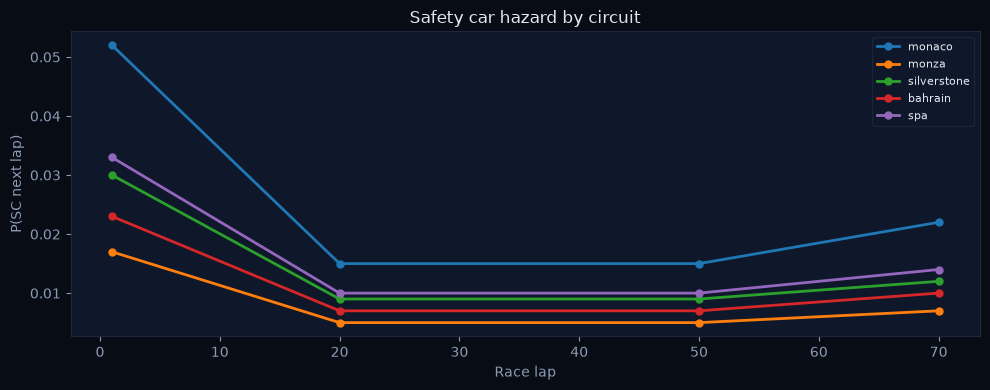

In [6]:
try:
    from pitwall.models.safety_car.hazard import SafetyCarHazardModel
    sc = SafetyCarHazardModel()
    circuits = ["monaco", "monza", "silverstone", "bahrain", "spa"]
    all_probs = {}
    print(f"{'Circuit':<14} {'Lap 1':>8} {'Lap 20':>8} {'Lap 50':>8} {'Lap 70':>8}")
    print("-" * 50)
    for circuit in circuits:
        probs = []
        for lap in [1, 20, 50, 70]:
            h = sc.predict_hazard(circuit_id=circuit, lap_number=lap, total_laps=78)
            probs.append(h.p_sc_next_1)
        all_probs[circuit] = probs
        print(f"{circuit:<14} " + "  ".join(f"{p:.1%}" for p in probs))

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor("#080c14"); ax.set_facecolor("#0f172a")
    x = [1, 20, 50, 70]
    for circuit, probs in all_probs.items():
        ax.plot(x, probs, marker="o", label=circuit, linewidth=2, markersize=5)
    ax.set_xlabel("Race lap"); ax.set_ylabel("P(SC next lap)")
    ax.set_title("Safety car hazard by circuit")
    ax.legend(facecolor="#0f172a", edgecolor="#1e293b", fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Safety car model unavailable: {e}")

## Takeaways

- The optimal pit lap shifts by compound: SOFT wants the earliest stop (pace now, degradation later), HARD the latest (needs laps to pay back).
- The undercut model's threshold behaviour is sharp by construction — treat the 1.8s as a tunable prior, not a law.
- SC hazard is dominated by the circuit prior and lap 1; it's a heuristic layer, not a learned model — honest about that.

Next: drift detection and MLOps (notebook 05).